# **Week 0 Main Assignment**

### Read Lisan_Al_Gaib.pdf for problem description and complete the following functions

In [2]:
import time # to time the execution
import numpy as np
import matplotlib.pyplot as plt

In [5]:
### TODO 1
### Load data from data_path
### Check the input file spice_locations.txt to understand the Data Format
### Return : np array of size Nx2
def load_data(data_path):
    data = np.loadtxt(data_path, delimiter=",").reshape(-1, 2)
    data = data.astype(float)
    return data

load_data("spice_locations.txt")

array([[-2.12729941e+00,  1.75357153e+00],
       [-3.40030291e-01, -6.70757901e-03],
       [-3.21990680e+00, -2.22002740e+00],
       [-3.70958194e+00,  1.33088073e+00],
       [-9.94424941e-01,  5.40362889e-01],
       [-3.89707753e+00,  1.84954926e+00],
       [ 1.62213204e-01, -1.93830445e+00],
       [-3.09087516e+00, -2.08297745e+00],
       [-2.47878879e+00, -3.76217842e-01],
       [-1.84027491e+00, -1.54385430e+00],
       [-9.40735526e-01, -2.30253070e+00],
       [-2.53927676e+00, -1.16819078e+00],
       [-1.71965008e+00,  9.25879807e-01],
       [-3.00163109e+00, -4.28827808e-01],
       [-1.03792716e+00, -2.76774794e+00],
       [-9.62275740e-01, -2.14737938e+00],
       [-3.67474204e+00,  1.74442769e+00],
       [ 8.28160165e-01,  1.04198674e+00],
       [-2.47693115e+00, -2.51163943e+00],
       [-5.78834867e-01, -7.99237531e-01],
       [-3.38980883e+00, -5.24115449e-01],
       [-3.82805739e+00,  1.54660201e+00],
       [-2.70610009e+00,  3.12611422e-01],
       [-2.

In [7]:
### TODO 2.1
### If init_centers is None, initialize the centers by selecting K data points at random without replacement
### Else, use the centers provided in init_centers
### Return : np array of size Kx2
def initialise_centers(data, K, init_centers=None):
    if init_centers is None:
        centers = data[np.random.choice(data.shape[0], K, replace=False)]
    else:
        centers = np.array(init_centers)
    return centers


In [8]:
### TODO 2.2
### Initialize the labels to all ones to size (N,) where N is the number of data points
### Return : np array of size N
def initialise_labels(data):
    labels = np.ones(data.shape[0], dtype=int)
    return labels
    

In [18]:
### TODO 3.1 : E step
### For Each data point, find the distance to each center
### Return : np array of size NxK
def calculate_distances(data, centers):
    n=data.shape[0]
    k=centers.shape[0]
    arr=np.ones(n*k).reshape(n,k)
    for i in range(0,k):
        for j in range(0,n):
            dist=np.sqrt((centers[i][0]-data[j][0])**2 + (centers[i][1]-data[j][1])**2)
            arr[j][i]=dist
    return arr

In [16]:
### TODO 3.2 : E step
### For Each data point, assign the label of the nearest center
### Return : np array of size N
def update_labels(distances):
    labels = np.argmin(distances, axis=1)
    return labels

In [27]:
### TODO 4 : M step
### Update the centers to the mean of the data points assigned to it
### Return : np array of size Kx2


def update_centers(data, labels, K):
   
    centers = np.zeros((K, data.shape[1]))
    
    for i in range(K):
       
        cluster_points = data[labels == i]
        
        
        if len(cluster_points) > 0:
            centers[i] = np.mean(cluster_points, axis=0)
        else:
            centers[i] = 0  
            
    return centers


In [12]:
### TODO 6 : Check convergence
### Check if the labels have changed from the previous iteration
### Return : True / False
def check_termination(labels1, labels2):
    return np.array_equal(labels1, labels2)

In [14]:
### DON'T CHANGE ANYTHING IN THE FOLLOWING FUNCTION
def kmeans(data_path:str, K:int, init_centers):
    '''
    Input :
        data (type str): path to the file containing the data
        K (type int): number of clusters
        init_centers (type numpy.ndarray): initial centers. shape = (K, 2) or None
    Output :
        centers (type numpy.ndarray): final centers. shape = (K, 2)
        labels (type numpy.ndarray): label of each data point. shape = (N,)
        time (type float): time taken by the algorithm to converge in seconds
    N is the number of data points each of shape (2,)
    '''
    data = load_data(data_path)    
    centers = initialise_centers(data, K, init_centers)
    labels = initialise_labels(data)

    start_time = time.time() # Time stamp 

    while True:
        distances = calculate_distances(data, centers)
        labels_new = update_labels(distances)
        centers = update_centers(data, labels_new, K)
        if check_termination(labels, labels_new): break
        else: labels = labels_new
 
    end_time = time.time() # Time stamp after the algorithm ends
    return centers, labels, end_time - start_time 

In [31]:
### TODO 7
def visualise(data_path, labels, centers):
    
    data=load_data(data_path)
    # Scatter plot of the data points
    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='viridis', marker='o')
    # Scatter plot of the centers
    plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X')
    ### Set title as 'K-means clustering'
    plt.title('K-means clustering')
    ### Set xlabel as 'Longitude'
    plt.xlabel('Longitude')
    ### Set ylabel as 'Latitude'
    plt.ylabel('Latitude')
    ### Save the plot as 'kmeans.png'
    plt.savefig('kmeans.png')

    ## DO NOT CHANGE THE FOLLOWING LINE
    return plt

Time taken for the algorithm to converge: 0.0016558170318603516


<module 'matplotlib.pyplot' from 'c:\\Users\\Atharva\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\matplotlib\\pyplot.py'>

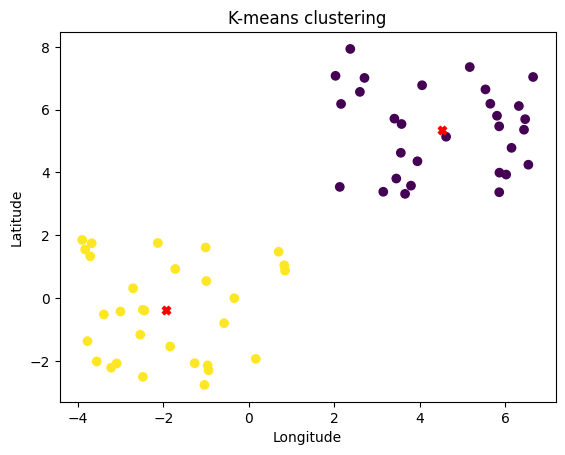

In [32]:
### After you have completed the above functions, run the following code to generate the plot
data_path = 'spice_locations.txt'
K, init_centers = 2, None
centers, labels, time_taken = kmeans(data_path, K, init_centers)
print('Time taken for the algorithm to converge:', time_taken)
visualise(data_path, labels, centers)